# Research Objectives

For each key in the test set, you must predict a value for the fare_amount variable. The evaluation metric for this competition is the root mean-squared error or RMSE.

# Data Wrangling 

## Loading library & Data

- train.csv - Input features and target fare_amount values for the training set. Only 01 Million rows are seleted out of 55 M due to memory restriction on local machine.
- test.csv - Input features for the test set (about 10K rows). Goal is to predict fare_amount for each row.
- sample_submission.csv - a sample submission file in the correct format (columns key and fare_amount). This file 'predicts' fare_amount to be $11.35 for all rows, which is the mean fare_amount from the training set.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(palette="viridis",rc={"figure.figsize": (8, 5)})
train = pd.read_csv('data.nosync/train.csv', nrows=1000000)
train.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


## Data Cleaning & Feature Engineering

In [2]:
print("--- Missing Values Per Column ---")

print(train.isna().sum())

print("--- Data Types ---")
print(train.dtypes)

--- Missing Values Per Column ---
key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64
--- Data Types ---
key                      str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


In [3]:
print("--- Descriptive Summary ---")
print(train.describe())

--- Descriptive Summary ---
          fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  1000000.000000    1000000.000000   1000000.000000      999990.000000   
mean        11.348079        -72.526640        39.929008         -72.527860   
std          9.822090         12.057937         7.626154          11.324494   
min        -44.900000      -3377.680935     -3116.285383       -3383.296608   
25%          6.000000        -73.992060        40.734965         -73.991385   
50%          8.500000        -73.981792        40.752695         -73.980135   
75%         12.500000        -73.967094        40.767154         -73.963654   
max        500.000000       2522.271325      2621.628430          45.581619   

       dropoff_latitude  passenger_count  
count     999990.000000   1000000.000000  
mean          39.919954         1.684924  
std            8.201418         1.323911  
min        -3114.338567         0.000000  
25%           40.734046         1.000000  
50

In [4]:
upper_limit = train["fare_amount"].quantile(0.75)+1.5*stats.iqr(train["fare_amount"])
lower_limit = train["fare_amount"].quantile(0.25)-1.5*stats.iqr(train["fare_amount"])
outliers = (train["fare_amount"]<=lower_limit) & (train["fare_amount"]>=upper_limit)
print(f"""
----  Fare  Amount Analysis  ----

    Upper limit: {upper_limit},
    Lower limit: {lower_limit},
    Outliers percentage: {len(train[outliers])*100.00/len(train)},
    Negative price in : {len(train[train["fare_amount"]<0])} Rows
    """)


----  Fare  Amount Analysis  ----

    Upper limit: 22.25,
    Lower limit: -3.75,
    Outliers percentage: 0.0,
    Negative price in : 38 Rows
    


In [5]:
print("--- Removing negative 38 rows ---\n")
train_clean =train[train["fare_amount"]>=0]
train_clean["pickup_datetime"]=pd.to_datetime(train_clean["pickup_datetime"],errors="coerce")
train_clean["year"]=train_clean["pickup_datetime"].dt.year
train_clean["month"]=train_clean["pickup_datetime"].dt.month
train_clean["hour"]=train_clean["pickup_datetime"].dt.hour

--- Removing negative 38 rows ---



# Exploratory Data Analysis (EDA)

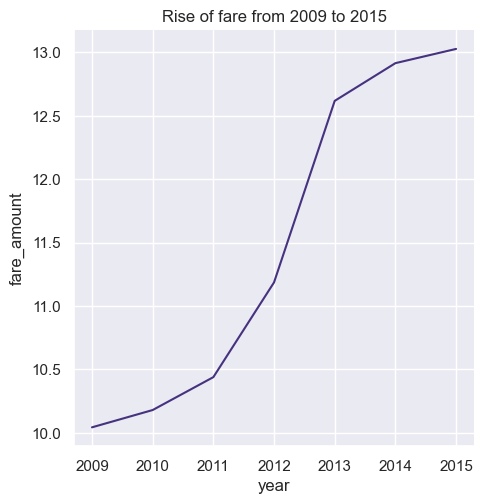

In [6]:
sns.relplot(x="year",y="fare_amount",data=train_clean,kind="line",errorbar=None)
plt.title("Rise of fare from 2009 to 2015")
plt.show()

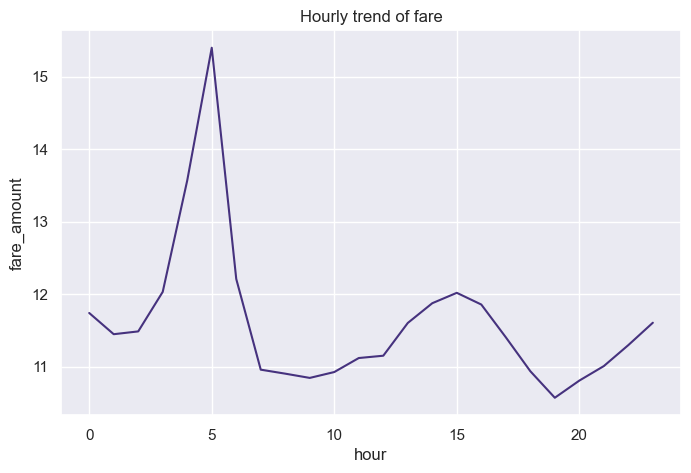

In [7]:
sns.lineplot(x="hour",y="fare_amount",data=train_clean,errorbar=None)
plt.title("Hourly trend of fare")
plt.show()

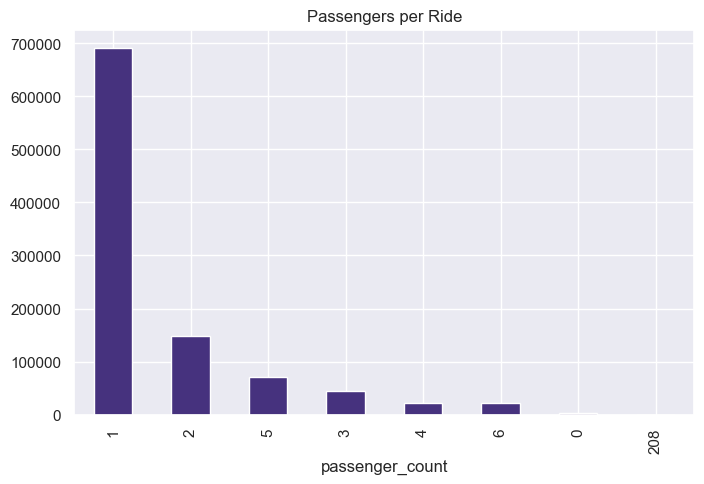

In [8]:
train_clean["passenger_count"].value_counts().plot(kind="bar")
plt.title("Passengers per Ride")
plt.show()

In [9]:
print(f"Number of rows with either 0 and one instance of 208 passengers are : \
{len(train_clean[train_clean['passenger_count'].isin([208,0])])}\n")

print("--- Removing thses outliers ---\n")
train_clean=train_clean[~train_clean["passenger_count"].isin([208,0])]

Number of rows with either 0 and one instance of 208 passengers are : 3566

--- Removing thses outliers ---



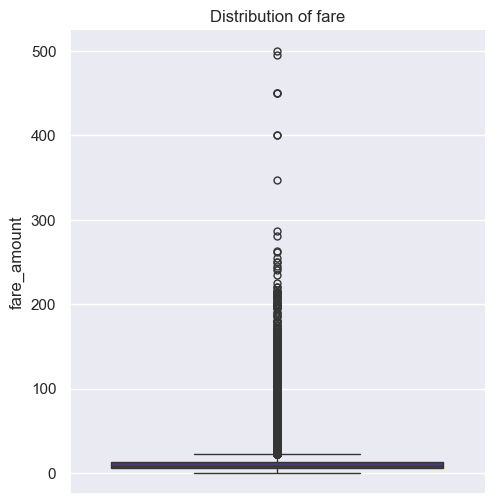

In [10]:
sns.catplot(y="fare_amount",data=train_clean,kind="box")
plt.title("Distribution of fare")
plt.show()